# 1.Project tittle

# AI-Based Image Data Annotation using Python

### Training Project

**Developed By:** Mahima Prajapati

**Technology:** Python, OpenCV, YOLOv8, Pandas, Matplotlib

# 2.Install Libraries

In [4]:
!pip install ultralytics
!pip install opencv-python
!pip install matplotlib
!pip install pandas
!pip install pillow

# 3.Import Libraries

In [5]:
import cv2
import os
import pandas as pd
import matplotlib.pyplot as plt
from ultralytics import YOLO
from PIL import Image

Creating new Ultralytics Settings v0.0.6 file  
View Ultralytics Settings with 'yolo settings' or at 'C:\Users\disha\AppData\Roaming\Ultralytics\settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


# 4.Create Project Folders

In [6]:
os.makedirs("images", exist_ok=True)
os.makedirs("annotations", exist_ok=True)
os.makedirs("outputs", exist_ok=True)

print("Folders Ready")

Folders Ready


# 5.Load Dataset

In [8]:
import os

image_folder = "images"

images = os.listdir(image_folder)

print("Total Images:", len(images))
print(images[:10])   

Total Images: 128
['000000000009.jpg', '000000000025.jpg', '000000000030.jpg', '000000000034.jpg', '000000000036.jpg', '000000000042.jpg', '000000000049.jpg', '000000000061.jpg', '000000000064.jpg', '000000000071.jpg']


# 6.Load YOLO Model

In [9]:
from ultralytics import YOLO

model = YOLO("yolov8n.pt")

print("✅ YOLO Model Loaded Successfully")

✅ YOLO Model Loaded Successfully


# 7.Detect Objects on One Image

In [32]:
image_path = os.path.join(image_folder, images[0])

results = model(image_path)


image 1/1 C:\Users\disha\OneDrive\Documents\Desktop\Data_Annotataion project\images\000000000009.jpg: 480x640 4 bowls, 1 broccoli, 1 hot dog, 206.1ms
Speed: 3.3ms preprocess, 206.1ms inference, 2.2ms postprocess per image at shape (1, 3, 480, 640)


# 8.Show Annotated Image

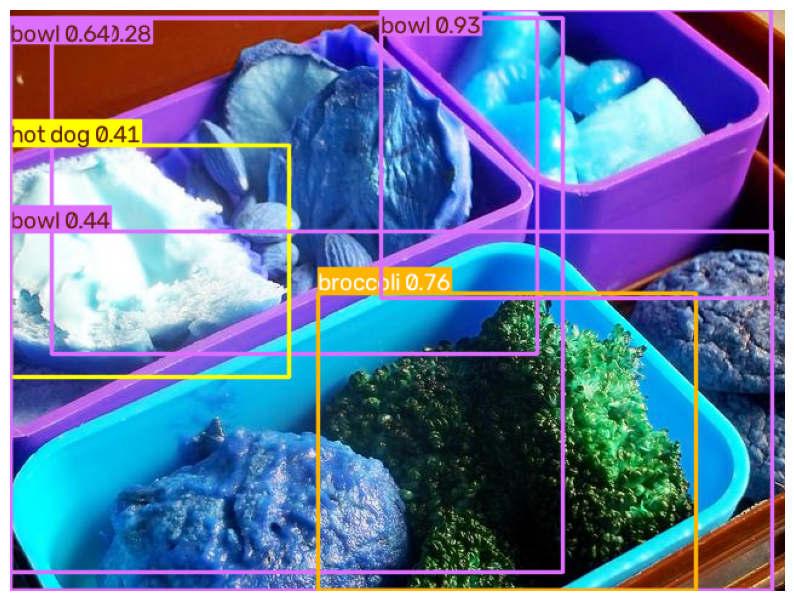

In [33]:
import matplotlib.pyplot as plt

result = results[0]

annotated = result.plot()

plt.figure(figsize=(10,8))
plt.imshow(annotated)
plt.axis("off")
plt.show()

# 9.Save Annotation CSV

In [12]:
import pandas as pd

annotation_data = []

for box in result.boxes:
    cls = int(box.cls[0])
    label = model.names[cls]
    confidence = float(box.conf[0])

    x1, y1, x2, y2 = box.xyxy[0].tolist()

    annotation_data.append({
        "Label": label,
        "Confidence": round(confidence, 2),
        "X1": round(x1, 2),
        "Y1": round(y1, 2),
        "X2": round(x2, 2),
        "Y2": round(y2, 2)
    })

df = pd.DataFrame(annotation_data)

df

,Label,Confidence,X1,Y1,X2,Y2
0,bowl,0.93,306.17,0.04,628.67,238.12
1,broccoli,0.76,254.71,234.24,566.59,479.73
2,bowl,0.64,0.00,7.75,456.39,464.02
3,bowl,0.44,0.81,183.75,629.97,479.33
4,hot dog,0.41,0.33,112.99,230.32,303.61
5,bowl,0.28,34.83,7.10,435.31,284.30


In [13]:
df.to_csv("annotations/annotations.csv", index=False)

print("✅ Annotation CSV Saved Successfully!")

✅ Annotation CSV Saved Successfully!


In [14]:
df.head()

,Label,Confidence,X1,Y1,X2,Y2
0,bowl,0.93,306.17,0.04,628.67,238.12
1,broccoli,0.76,254.71,234.24,566.59,479.73
2,bowl,0.64,0.00,7.75,456.39,464.02
3,bowl,0.44,0.81,183.75,629.97,479.33
4,hot dog,0.41,0.33,112.99,230.32,303.61


# 10.Batch Annotation

In [15]:
import os
import cv2
import pandas as pd

# Folders
image_folder = "images"
output_folder = "outputs"

os.makedirs(output_folder, exist_ok=True)

annotation_data = []

# Images ki list
images = [img for img in os.listdir(image_folder)
          if img.endswith((".jpg", ".jpeg", ".png"))]

print("Total Images:", len(images))

for img_name in images:

    image_path = os.path.join(image_folder, img_name)

    results = model(image_path)

    result = results[0]

    # Annotated image save
    annotated = result.plot()

    output_path = os.path.join(output_folder, img_name)

    cv2.imwrite(output_path, cv2.cvtColor(annotated, cv2.COLOR_RGB2BGR))

    # CSV data
    for box in result.boxes:

        cls = int(box.cls[0])

        label = model.names[cls]

        confidence = float(box.conf[0])

        x1, y1, x2, y2 = box.xyxy[0].tolist()

        annotation_data.append([
            img_name,
            label,
            round(confidence,2),
            round(x1,2),
            round(y1,2),
            round(x2,2),
            round(y2,2)
        ])

print("✅ Annotation Completed")

Total Images: 128

image 1/1 C:\Users\disha\OneDrive\Documents\Desktop\Data_Annotataion project\images\000000000009.jpg: 480x640 4 bowls, 1 broccoli, 1 hot dog, 155.4ms
Speed: 5.6ms preprocess, 155.4ms inference, 2.5ms postprocess per image at shape (1, 3, 480, 640)

image 1/1 C:\Users\disha\OneDrive\Documents\Desktop\Data_Annotataion project\images\000000000025.jpg: 448x640 2 giraffes, 129.1ms
Speed: 2.3ms preprocess, 129.1ms inference, 1.7ms postprocess per image at shape (1, 3, 448, 640)

image 1/1 C:\Users\disha\OneDrive\Documents\Desktop\Data_Annotataion project\images\000000000030.jpg: 448x640 1 potted plant, 1 vase, 93.2ms
Speed: 2.8ms preprocess, 93.2ms inference, 2.0ms postprocess per image at shape (1, 3, 448, 640)

image 1/1 C:\Users\disha\OneDrive\Documents\Desktop\Data_Annotataion project\images\000000000034.jpg: 448x640 1 zebra, 94.2ms
Speed: 5.0ms preprocess, 94.2ms inference, 1.6ms postprocess per image at shape (1, 3, 448, 640)

image 1/1 C:\Users\disha\OneDrive\Docume

# 11.Save all_annotations.csv

In [16]:
columns = [
    "Image",
    "Label",
    "Confidence",
    "X1",
    "Y1",
    "X2",
    "Y2"
]

df = pd.DataFrame(annotation_data, columns=columns)

df.to_csv("annotations/all_annotations.csv", index=False)

print("✅ CSV Saved Successfully")

✅ CSV Saved Successfully


In [17]:
df.head(20)

,Image,Label,Confidence,X1,Y1,X2,Y2
0,000000000009.jpg,bowl,0.93,306.17,0.04,628.67,238.12
1,000000000009.jpg,broccoli,0.76,254.71,234.24,566.59,479.73
2,000000000009.jpg,bowl,0.64,0.00,7.75,456.39,464.02
3,000000000009.jpg,bowl,0.44,0.81,183.75,629.97,479.33
4,000000000009.jpg,hot dog,0.41,0.33,112.99,230.32,303.61
5,000000000009.jpg,bowl,0.28,34.83,7.10,435.31,284.30
6,000000000025.jpg,giraffe,0.90,383.39,64.21,597.72,358.11
7,000000000025.jpg,giraffe,0.38,49.32,357.12,153.34,416.09
8,000000000030.jpg,vase,0.89,239.98,155.11,408.33,351.51
9,000000000030.jpg,potted plant,0.27,204.53,32.79,458.92,351.13


# 12.Statistics

In [18]:
print("Total Images :", len(images))
print("Total Objects :", len(df))

print("\nObjects Detected:\n")

print(df["Label"].value_counts())

Total Images : 128
Total Objects : 642

Objects Detected:

Label
person          200
chair            35
bowl             22
donut            20
dining table     16
               ... 
cow               1
skis              1
sandwich          1
bear              1
toilet            1
Name: count, Length: 68, dtype: int64


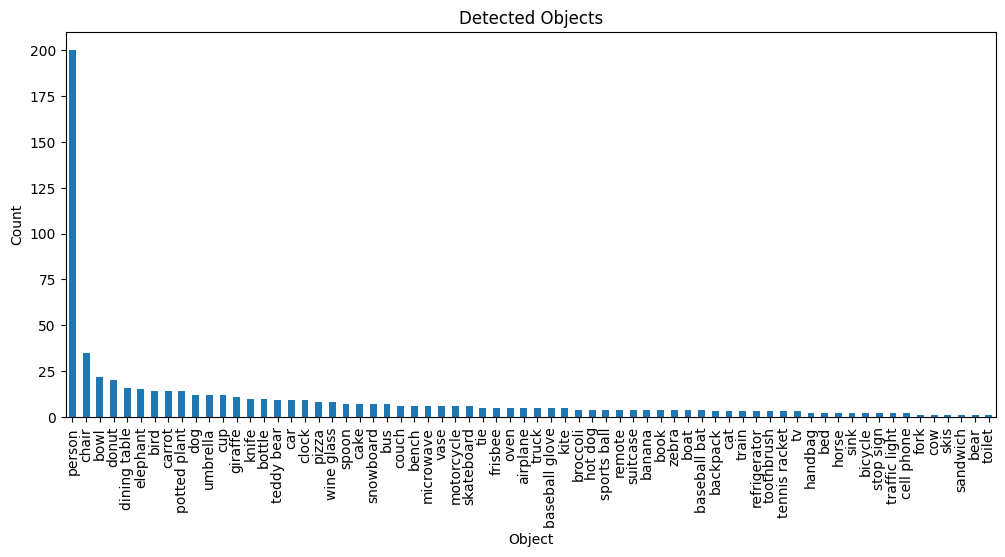

In [19]:
import matplotlib.pyplot as plt

df["Label"].value_counts().plot(kind="bar", figsize=(12,5))

plt.title("Detected Objects")

plt.xlabel("Object")

plt.ylabel("Count")

plt.show()

In [20]:
label = input("Enter Object Name : ")

result = df[df["Label"].str.lower() == label.lower()]

print(result)


Enter Object Name :  person


                Image   Label  Confidence      X1      Y1      X2      Y2
11   000000000036.jpg  person        0.90  173.89  158.23  462.01  639.56
18   000000000049.jpg  person        0.57  280.57  328.54  295.63  360.37
19   000000000049.jpg  person        0.51  189.04  332.13  198.80  358.69
20   000000000049.jpg  person        0.44  118.51  338.68  130.96  368.09
21   000000000049.jpg  person        0.36  357.67  339.05  376.94  361.40
..                ...     ...         ...     ...     ...     ...     ...
628  000000000634.jpg  person        0.56  177.11   16.09  197.52   38.76
629  000000000634.jpg  person        0.46  149.48   17.94  167.95   45.75
634  000000000641.jpg  person        0.30  571.26  236.11  582.80  278.57
635  000000000641.jpg  person        0.27  562.56  248.77  578.11  288.14
636  000000000641.jpg  person        0.27  568.61  237.97  581.38  284.33

[200 rows x 7 columns]


In [21]:
highest = df.loc[df["Confidence"].idxmax()]

print("Highest Confidence Detection")
print(highest)

Highest Confidence Detection
Image         000000000394.jpg
Label                  frisbee
Confidence                 1.0
X1                      235.31
Y1                      184.93
X2                      592.23
Y2                      476.91
Name: 388, dtype: object


# 13.Top 10 Bar Chart

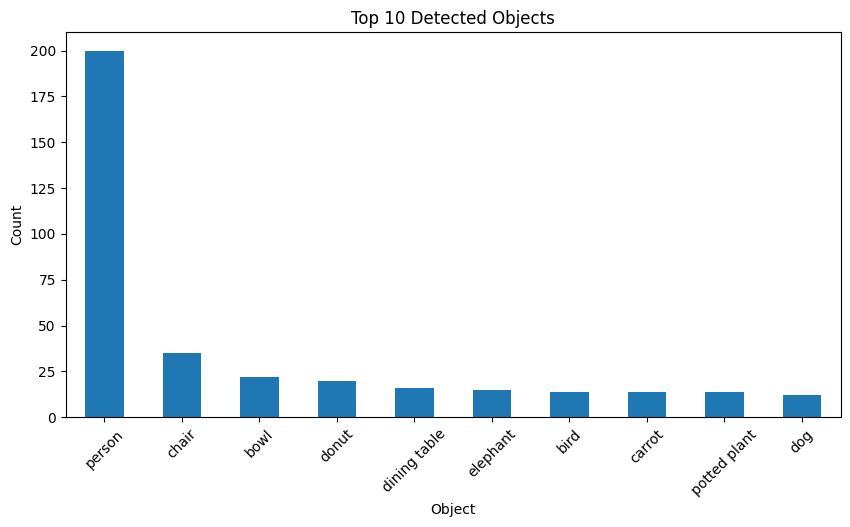

In [23]:
import matplotlib.pyplot as plt

top10 = df["Label"].value_counts().head(10)

plt.figure(figsize=(10,5))
top10.plot(kind="bar")

plt.title("Top 10 Detected Objects")
plt.xlabel("Object")
plt.ylabel("Count")

plt.xticks(rotation=45)

plt.show()

# 14.Top 5 Pie Chart

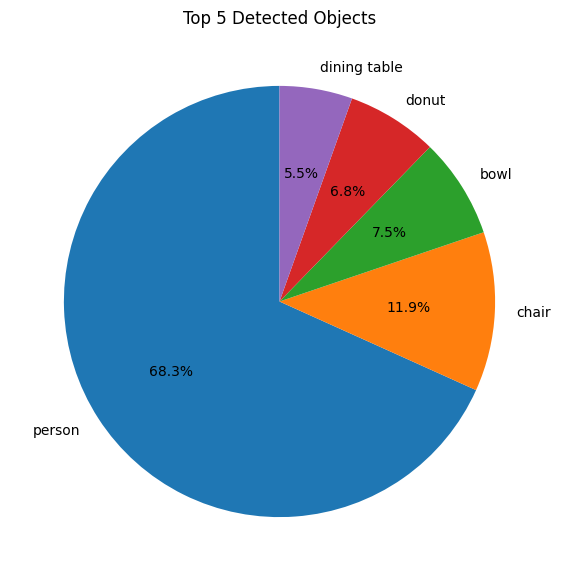

In [24]:
import matplotlib.pyplot as plt

top5 = df["Label"].value_counts().head(5)

plt.figure(figsize=(7,7))
plt.pie(top5,
        labels=top5.index,
        autopct="%1.1f%%",
        startangle=90)

plt.title("Top 5 Detected Objects")
plt.show()

# 15.Confidence Histogram

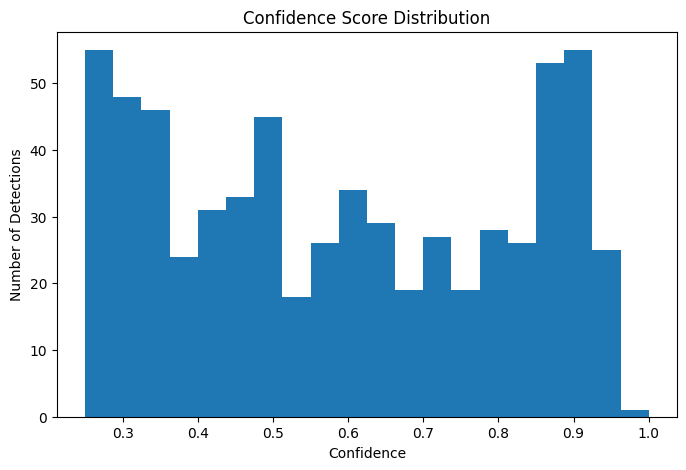

In [27]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.hist(df["Confidence"], bins=20)

plt.title("Confidence Score Distribution")
plt.xlabel("Confidence")
plt.ylabel("Number of Detections")

plt.show()

In [28]:
top_confidence = df.sort_values(by="Confidence", ascending=False)

top_confidence.head(10)

,Image,Label,Confidence,X1,Y1,X2,Y2
388,000000000394.jpg,frisbee,1.00,235.31,184.93,592.23,476.91
410,000000000428.jpg,person,0.95,229.22,30.07,582.62,356.36
59,000000000089.jpg,oven,0.95,138.75,204.03,478.58,479.27
417,000000000438.jpg,donut,0.94,476.23,195.54,600.90,312.60
453,000000000471.jpg,bus,0.94,115.08,108.57,576.80,323.29
591,000000000599.jpg,remote,0.94,438.33,201.32,615.88,283.93
504,000000000536.jpg,person,0.94,290.65,132.72,447.77,335.82
161,000000000154.jpg,zebra,0.94,16.78,315.30,358.97,639.74
287,000000000312.jpg,elephant,0.94,0.76,186.87,229.92,393.03
379,000000000389.jpg,tie,0.94,306.18,301.43,372.90,480.00


In [29]:
print("========== PROJECT SUMMARY ==========")
print("Total Images :", len(images))
print("Total Objects Detected :", len(df))
print("Unique Object Classes :", df["Label"].nunique())
print("Average Confidence :", round(df["Confidence"].mean(),2))

========== PROJECT SUMMARY ==========
Total Images : 128
Total Objects Detected : 642
Unique Object Classes : 68
Average Confidence : 0.59


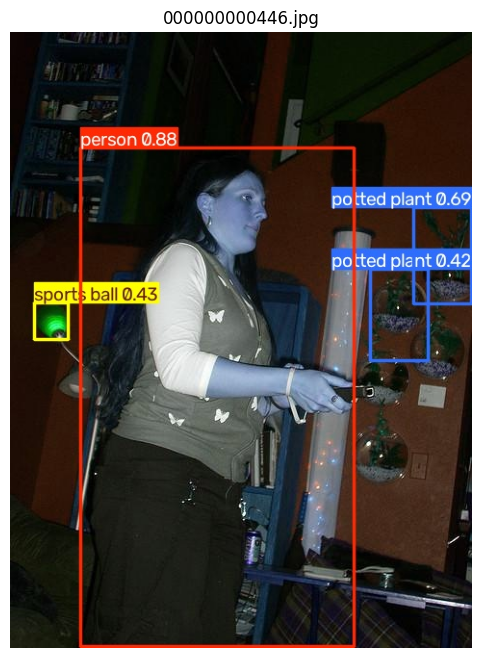

In [30]:
import random
import matplotlib.pyplot as plt
import cv2
import os

random_image = random.choice(images)

img = cv2.imread(os.path.join("outputs", random_image))
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(10,8))
plt.imshow(img)
plt.title(random_image)
plt.axis("off")
plt.show()

In [31]:
with open("outputs/project_summary.txt", "w") as file:
    file.write("IMAGE DATA ANNOTATION PROJECT\n")
    file.write("============================\n\n")
    file.write(f"Total Images : {len(images)}\n")
    file.write(f"Total Objects : {len(df)}\n")
    file.write(f"Unique Classes : {df['Label'].nunique()}\n")
    file.write(f"Average Confidence : {round(df['Confidence'].mean(),2)}\n")

print("Summary Saved Successfully!")

Summary Saved Successfully!
